In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('./datasets/diabetes/data_for_lr.csv')
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [65]:
print(df['y'].isna().sum())
print(df['x'].isna().sum())

1
0


In [66]:
df.shape

(700, 2)

In [67]:
df = df.dropna(subset=['y'])
df.shape

(699, 2)

In [68]:
print(df['y'].isna().sum())
print(df['x'].isna().sum())

0
0


In [69]:
df['xy'] = df['x'] * df['y']
df['x_sqr'] = df['x']**2

In [70]:
df.head(5)

,x,y,xy,x_sqr
0,24.0,21.549452,517.186847,576.0
1,50.0,47.464463,2373.223152,2500.0
2,15.0,17.218656,258.279845,225.0
3,38.0,36.586398,1390.283125,1444.0
4,87.0,87.288984,7594.141598,7569.0


In [71]:
# m = (n*sum_xy  - sum_x*sum_y) / n.sum_x2 - (sum_x)^2
# c = avg_y - m*avg_x

In [72]:
sum_xy = df['xy'].sum()
sum_x = df['x'].sum()
sum_y = df['y'].sum()
sum_x2 = df['x_sqr'].sum()

n = df.shape[0]

In [73]:
# m = (n*sum_xy  - sum_x*sum_y) / n*sum_x2 - (sum_x)**2

m = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - (sum_x)**2)

In [74]:

temp

np.float64(0.001431554194358089)

In [75]:
avg_x = df['x'].mean()
avg_y = df['y'].mean()
# temp = m/n

c = avg_y - m*avg_x

In [76]:
print(f' m = {m}')
print(f' c = {c}')

 m = 1.0006563818563041
 c = -0.10726546430097983


    - Using sklearn library

In [77]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [78]:
x = df[['x']]
y = df['y']

In [79]:
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
print(f' m = {model.coef_}')
print(f' c = {model.intercept_}')

 m = [1.00065638]
 c = -0.10726546430097272


In [81]:
df['y_pred'] = model.predict(x)

print(df.head())

      x          y           xy   x_sqr     y_pred
0  24.0  21.549452   517.186847   576.0  23.908488
1  50.0  47.464463  2373.223152  2500.0  49.925554
2  15.0  17.218656   258.279845   225.0  14.902580
3  38.0  36.586398  1390.283125  1444.0  37.917677
4  87.0  87.288984  7594.141598  7569.0  86.949840


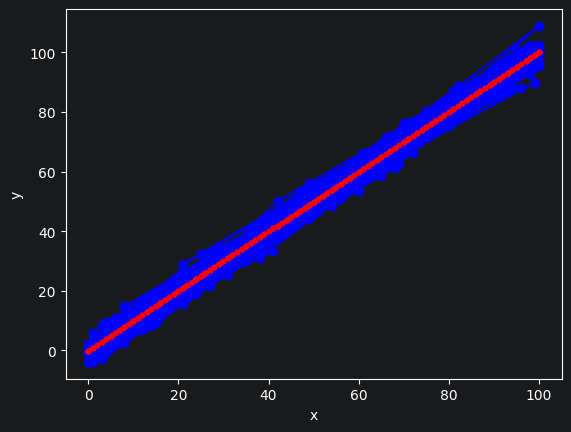

In [87]:
plt.plot(df['x'], df['y'],
         color='blue',
         marker='o',
         markerfacecolor='blue',
         )

plt.plot(df['x'], df['y_pred'],
         color='red',
         marker='.',
         markerfacecolor='red')

plt.xlabel('x')
plt.ylabel('y')
plt.show()

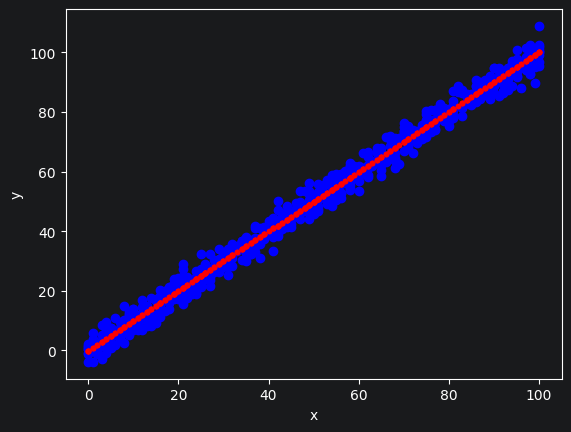

In [88]:
plt.plot(df['x'], df['y'],
         color='blue',
         marker='o',
         markerfacecolor='blue',
         linestyle='none',
         )

plt.plot(df['x'], df['y_pred'],
         color='red',
         marker='.',
         markerfacecolor='red',
         linestyle='none',)

plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [89]:
from sklearn.metrics import r2_score

r2 = r2_score(df['y'], df['y_pred'])

print("R² =", r2)

R² = 0.9907015319025518


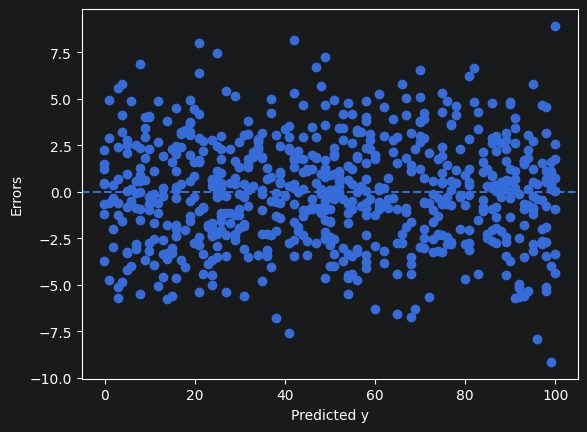

In [96]:
import math
errors = df['y'] - df['y_pred']

plt.scatter(df['y_pred'], errors)

plt.xlabel("Predicted y")
plt.ylabel("Errors")
plt.show()